# LSTM Classifier

In <a href=".4.MLVSDLClassifiers.ipynb">4.MLVSDLClassifiers.ipynb</a> we explored non-linear dimensionality reduction methods can allow useful relationships from developed markets to be learned and applied to emerging markets to counter the data quality issue; however, decoupling the embedding from the classification prevents features that usefully separate positive from negative crisis labels from being learned. Here we explore the extent to which a LSTM with a classifier head within the neural network can learn these separating features, if they even exist in this dataset.

In [1]:
from src.model.utilities import set_seed, set_device
seed = set_seed()
device = set_device()

from src.features.utilities import load_or_train_model

import pandas as pd
import numpy as np

import os
import dotenv
dotenv.load_dotenv()
username = os.getenv("HUGGINGFACE_USERNAME")

No GPU available! Running on CPU


## Data
Once again for data processing, we import the data at monthly resolution and drop the four crisis/recovery years that immediately follow a positive crisis label, replacing them with a historically-informed counterfactual with Gaussian noise such that we can pass complete sequences to the LSTM.

In [2]:
from datasets import load_dataset
from src.data.data_utilities import build_labels

# download monthly resolution data
datalink = f"{username}/imputed-monthly"
train_df = load_dataset(datalink, "developed", split='train').to_pandas()
test_df = load_dataset(datalink, "developed", split='test').to_pandas()
support_df = load_dataset(datalink, "emerging", split='train').to_pandas()
query_df = load_dataset(datalink, "emerging", split='test').to_pandas()

# build crisis labels
y_train = build_labels(train_df)
y_test = build_labels(test_df)
y_support = build_labels(support_df)
y_query = build_labels(query_df)

In [3]:
print(f"Developed train set shape: {train_df.shape}, n(countries): {train_df['Country'].nunique()}, labels shape: {y_train.shape}, % positive: {y_train.mean()*100:.2f}")
print(f"Developed test set shape: {test_df.shape}, n(countries): {test_df['Country'].nunique()}, labels shape: {y_test.shape}, % positive: {y_test.mean()*100:.2f}")
print(f"Emerging support set shape: {support_df.shape}, n(countries): {support_df['Country'].nunique()}, labels shape: {y_support.shape}, % positive: {y_support.mean()*100:.2f}")
print(f"Emerging query set shape: {query_df.shape}, n(countries): {query_df['Country'].nunique()}, labels shape: {y_query.shape}, % positive: {y_query.mean()*100:.2f}")


Developed train set shape: (9588, 400), n(countries): 17, labels shape: (9588,), % positive: 16.15
Developed test set shape: (3468, 400), n(countries): 17, labels shape: (3468,), % positive: 6.92
Emerging support set shape: (38617, 400), n(countries): 73, labels shape: (38617,), % positive: 16.31
Emerging query set shape: (14892, 400), n(countries): 73, labels shape: (14892,), % positive: 9.91


## Model
The model itself can be trained on focal loss to deal with class imbalance in the labels. This is what encourages the embedding space to be usefully designed to differentiate between positive and negative crisis labels, with emphasis on the difficult to classify examples as tuned with the $\gamma$ parameter. The best performing model was one that was tuned on precision-focused focal loss with low $\alpha$ so that the model was selective about where it predicted a positive crisis label. This addresses the overprediction issue that we observed with the ML classifiers.

Model type: <class 'src.model.architectures.LSTMClassifier'>


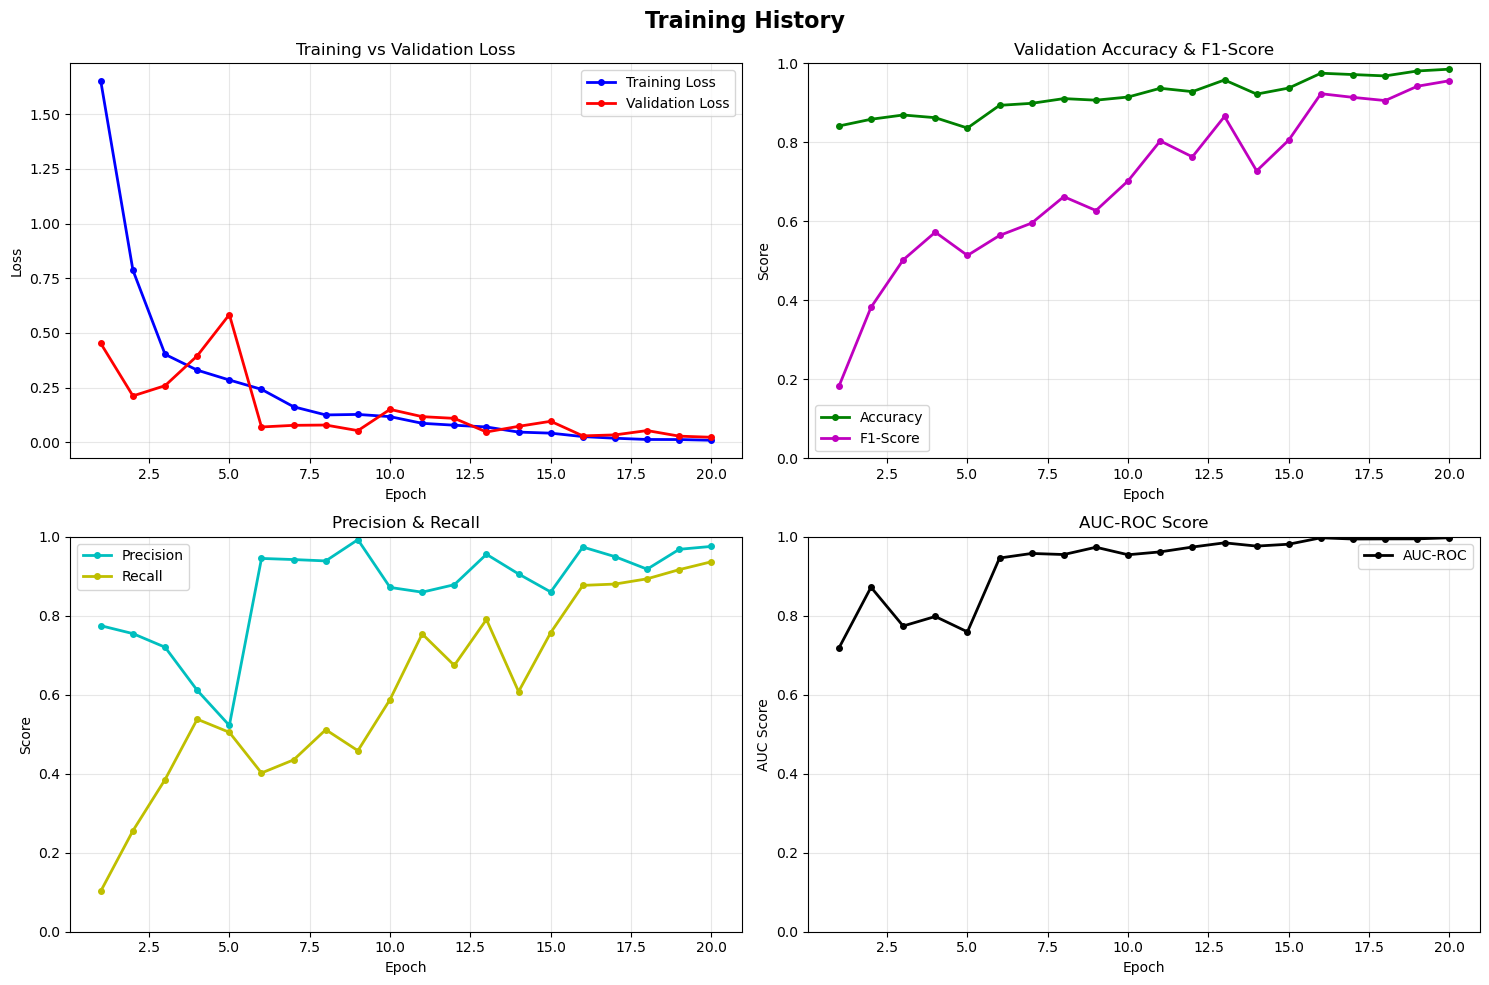

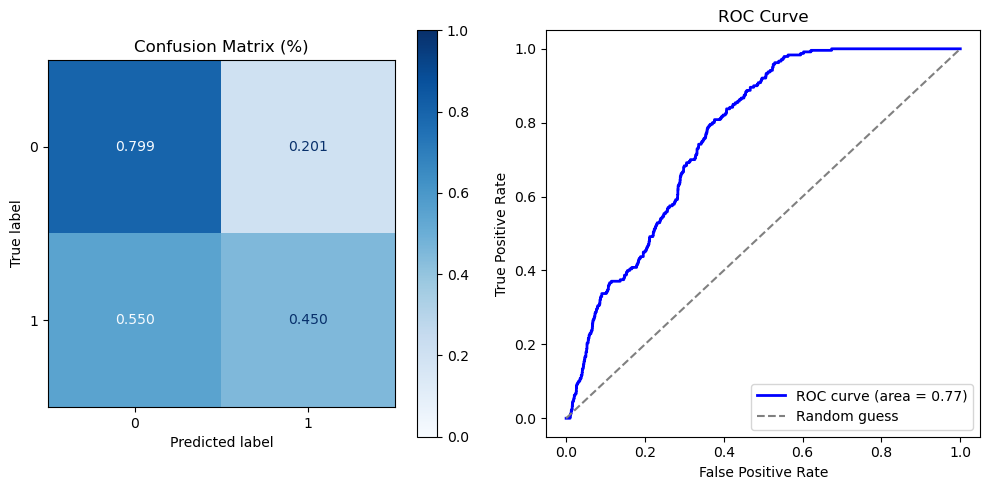

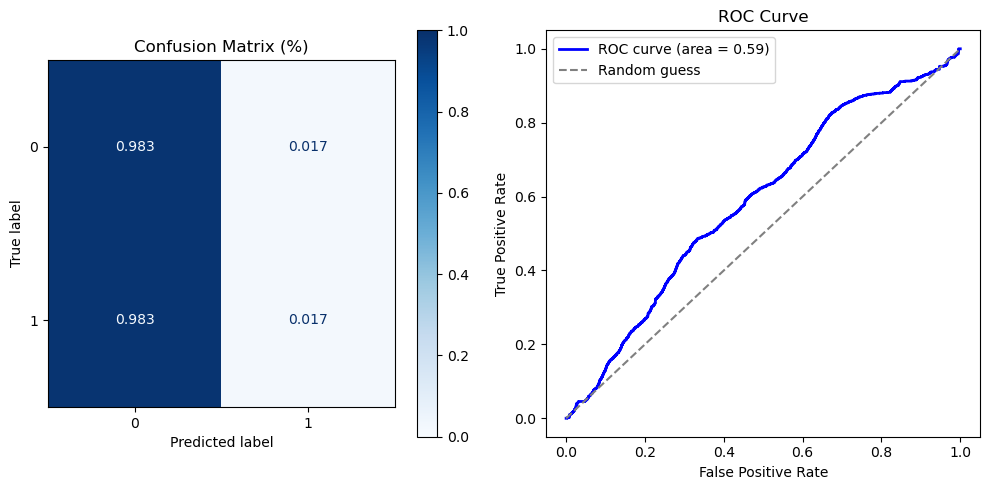

In [4]:
from src.model.architectures import LSTMClassifier
from src.model.loss import PrecisionFocalLoss
from src.model.classifiers import plot_metrics
from src.features.utilities import load_or_train_model
from src.model.utilities import plot_training_history

# choose LSTM Classifier parameters
params = {
    'sequence_length': 48,
    'lstm_units': 128,
    'num_lstm_layers': 3,
    'dense_units': [128, 64],
    'learning_rate': 8e-4,
    'batch_size': 64,
    'dropout_rate': 0.15,
    'n_epochs': 20,
    'use_attention': True,
    'use_residual': True,
    'Gaussian_noise': False,
    'noise_factor': 0.0,
    # counter-intuitively, reduced alpha to give less weight to the negative class
    # allowed model to be more selective about positive predictions
    'criterion': PrecisionFocalLoss(alpha=0.1, gamma=2.0, precision_weight=2.25)
}

# train or load LSTM classifier
lstm_classifier = load_or_train_model(
    model_class=LSTMClassifier,
    params=params,
    train_data=train_df,
    train_labels=y_train,
    force_retrain=False
)
# plot training history
print(f"Model type: {type(lstm_classifier)}")
plot_training_history(lstm_classifier.train_losses, lstm_classifier.val_losses, lstm_classifier.val_metrics_history)

# test_df: add last sequence_length-1 of train data to test data for each Country
indices = len(train_df['Country'].unique())*(params['sequence_length']-1)
add_df = train_df.sort_values('Date')[-indices:]
add_test_df = pd.concat([add_df, test_df], ignore_index=True)
y_test_extended = build_labels(add_test_df)

# query_df: add last sequence_length-1 of support data to query data for each Country
indices = len(support_df['Country'].unique())*(params['sequence_length']-1)
add_df = support_df.sort_values('Date')[-indices:]
add_query_df = pd.concat([add_df, query_df], ignore_index=True)
y_query_extended = build_labels(add_query_df)

# plot confusion matrix and AUC-ROC for test sets
plot_metrics(lstm_classifier, add_test_df, y_test_extended)
plot_metrics(lstm_classifier, add_query_df, y_query_extended)

## What has it learned?
The AUC-ROC curve for the developed test set is the best yet. As the positive crisis predictions are selective, we can attempt to investigate if the model has learned useful crisis precursors.

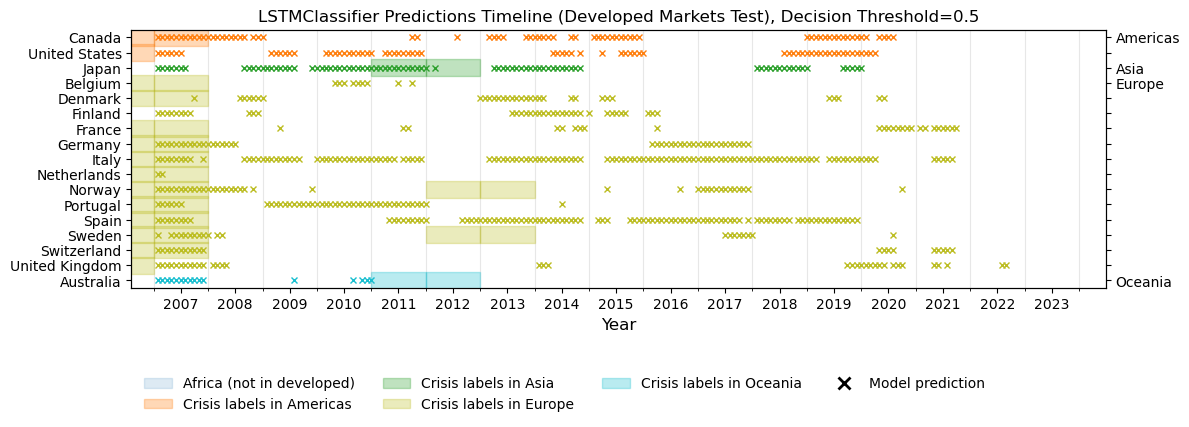

In [5]:
from src.visualizations.timeline import plot_prediction_timeline

# generate predictions
test_predictions = lstm_classifier.predict(add_test_df)
test_probabilities = lstm_classifier.predict_proba(add_test_df)[:, 1]

# add predictions to dataframe
predictions_df = test_df.copy()
predictions_df['y_pred'] = test_predictions
predictions_df['y_prob'] = test_probabilities
predictions_df['y_true'] = y_test

# plot predictions for developed markets
threshold=0.5
plot_prediction_timeline(
    model=lstm_classifier,
    data_df=predictions_df,
    subset='developed',
    title=f"LSTMClassifier Predictions Timeline (Developed Markets Test), Decision Threshold={threshold}",
    bar_height=1.1,
    threshold=threshold
)

United States (2022-2023): The periodicity of the positive prediction (from October 2022 to October 2023) suggests that the important feature here is something fiscal. During FY2023, budget deficit increased and was financed by borrowing from the public. (source: https://www.fiscal.treasury.gov/reports-statements/financial-report/2023/government-financial-position-and-condition.html)

Interest rates were high during this period to make U.S. Treasury securities more enticing. This is a feature the model was able to observe and put in context of the last four years. 

In [6]:
def get_positive_prediction_dates(predictions_df: pd.DataFrame, country: str) -> list:
    """
    Extract consecutive date ranges corresponding to positive predictions for a specific country.
    
    Parameters:
    -----------
    predictions_df : pd.DataFrame
        DataFrame containing predictions with columns 'Country', 'y_pred', and 'Date'
    country : str
        Name of the country to filter for
        
    Returns:
    --------
    list
        List of tuples (start_date, end_date) representing consecutive periods 
        where the model made positive predictions for the specified country
    """
    # Filter for the specific country and positive predictions
    country_data = predictions_df[predictions_df['Country'] == country].copy()
    positive_data = country_data[country_data['y_pred'] == 1].copy()
    
    if positive_data.empty:
        return []
    
    # Sort by date to ensure proper ordering
    positive_data = positive_data.sort_values('Date')
    
    # Convert dates to datetime if they're not already
    positive_data['Date'] = pd.to_datetime(positive_data['Date'])
    
    # Find consecutive date periods
    consecutive_periods = []
    start_date = positive_data.iloc[0]['Date']
    prev_date = start_date
    
    for i in range(1, len(positive_data)):
        current_date = positive_data.iloc[i]['Date']
        
        # Check if there's a gap (assuming monthly data, so gap > ~32 days)
        if (current_date - prev_date).days > 32:
            # End the current period
            consecutive_periods.append((start_date.strftime('%Y-%m-%d'), 
                                      prev_date.strftime('%Y-%m-%d')))
            # Start a new period
            start_date = current_date
        
        prev_date = current_date
    
    # Add the final period
    consecutive_periods.append((start_date.strftime('%Y-%m-%d'), 
                              prev_date.strftime('%Y-%m-%d')))
    
    return consecutive_periods

[*********************100%***********************]  1 of 1 completed


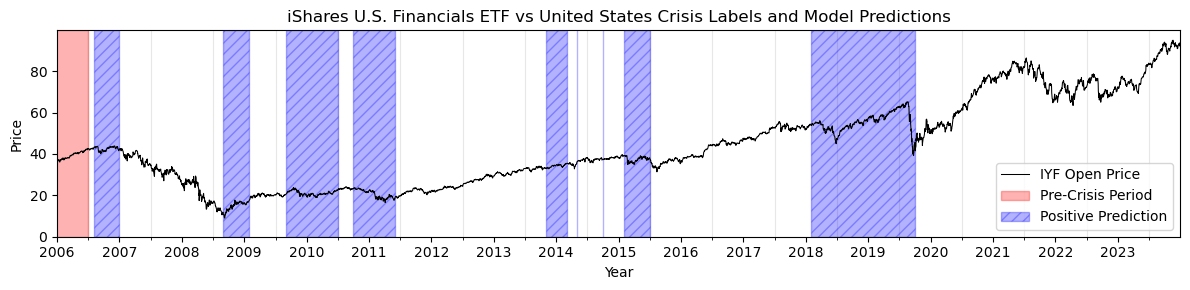

In [7]:
from src.visualizations.timeline import plot_ticker_vs_crises

plot_ticker_vs_crises(
    ticker='IYF', country='United States', figsize=(12,3),
    title="iShares U.S. Financials ETF vs United States Crisis Labels and Model Predictions",
    x_limits=('2006-07-01', '2024-06-30'),
    highlights=get_positive_prediction_dates(predictions_df, country='United States')
)

Japan (2021): Rapid yen depreciation; first yen-support FX intervention in 24 years. Bank of Japan widened the 10-year JGB yield cap band. Model prediction is positive during this period, likely because it picked up signals from government spending and import price shocks.

[*********************100%***********************]  1 of 1 completed


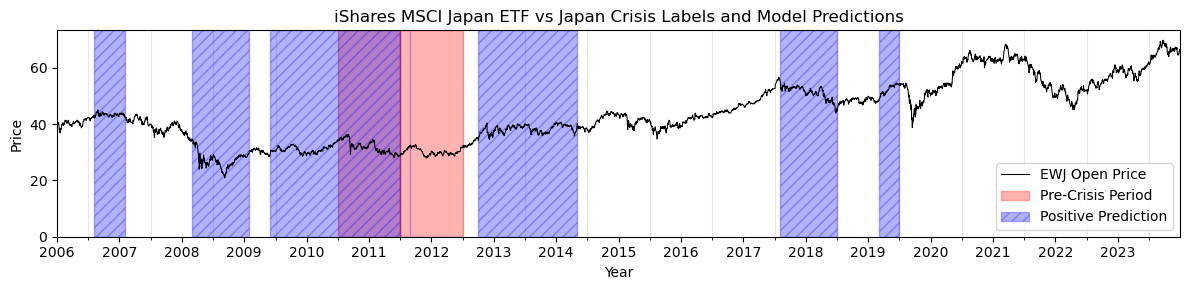

In [8]:
plot_ticker_vs_crises(
    ticker='EWJ', country='Japan', figsize=(12,3),
    title="iShares MSCI Japan ETF vs Japan Crisis Labels and Model Predictions",
    x_limits=('2006-07-01', '2024-06-30'),
    highlights=get_positive_prediction_dates(predictions_df, country='Japan')
)

Italy (2011): Italy's credit default swap (CDS) rate was incredibly high in 2011 and public debt was at its highest since WWI. S&P downgraded Italy's sovereign debt  and Berlusconi eventually resigned. (source: https://www.intereconomics.eu/contents/year/2011/number/6/article/italys-fiscal-crisis.html)

This probably was a short economic crisis that the model identified but did not provide a sufficiently early warning for.

[*********************100%***********************]  1 of 1 completed


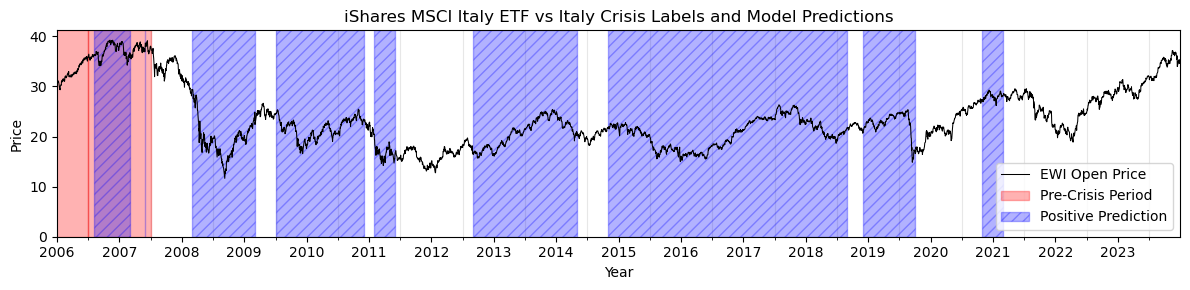

In [9]:
plot_ticker_vs_crises(
    ticker='EWI', country='Italy', figsize=(12,3),
    title="iShares MSCI Italy ETF vs Italy Crisis Labels and Model Predictions",
    x_limits=('2006-07-01', '2024-06-30'),
    highlights=get_positive_prediction_dates(predictions_df, country='Italy')
)

## Transfer Learning
Using the model as-is to predict on emerging markets shows very few positive crisis predictions. This is because the model has been tuned for precision-based focal loss on developed markets and this hyperfocus does not translate well to the emerging markets.

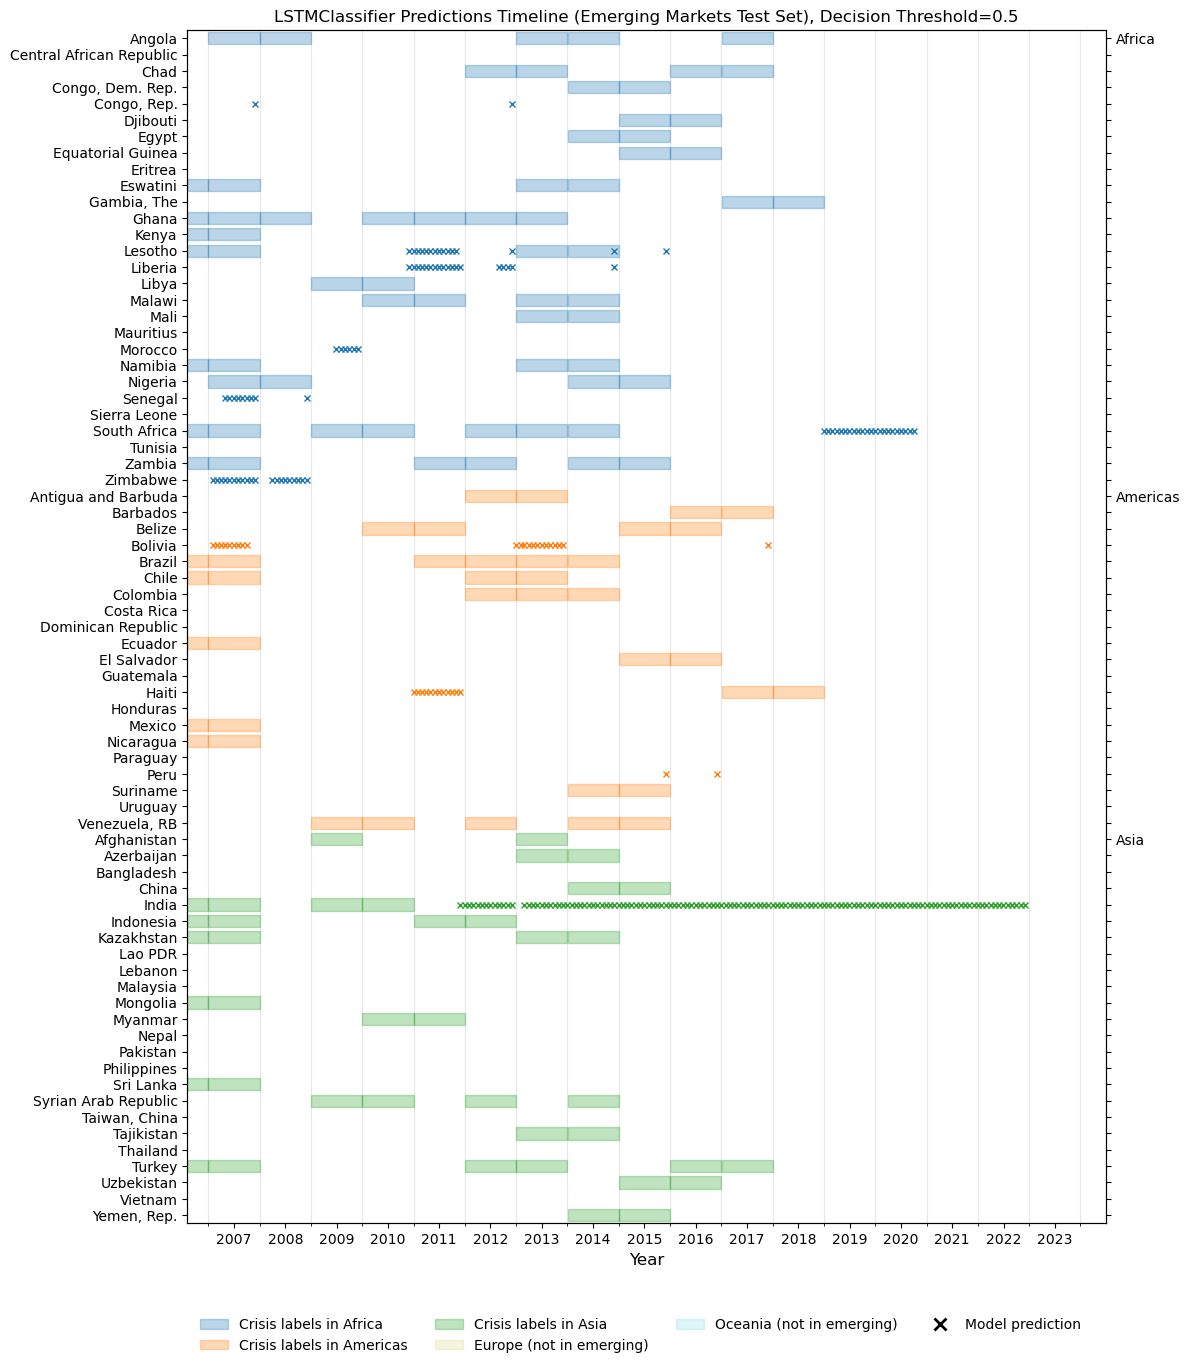

In [10]:
# generate predictions
test_predictions = lstm_classifier.predict(add_query_df)
test_probabilities = lstm_classifier.predict_proba(add_query_df)[:, 1]

# add predictions to dataframe
predictions_df = query_df.copy()
predictions_df['y_pred'] = test_predictions
predictions_df['y_prob'] = test_probabilities
predictions_df['y_true'] = y_query

# plot predictions for emerging markets
threshold=0.5
plot_prediction_timeline(
    model=lstm_classifier,
    data_df=predictions_df,
    subset='emerging',
    title=f"LSTMClassifier Predictions Timeline (Emerging Markets Test Set), Decision Threshold={threshold}",
    bar_height=0.75,
    threshold=threshold
)

We can instead fine-tune the model on emerging markets within the same training period. In general, there a few paramters that we can tune:
1. Proportion of layers
2. Number of fine-tuning epochs
3. Criterion (i.e. alpha, gamma, and precision weight of focal loss)
4. Learning rate
5. Batch size

For this experiment, we choose to only explore changes in 1-3 to understand how fundamentally different emerging market training data is from the developed market data and the extent to which a model needs to be fine-tuned.

In [11]:
import copy
import torch
import gc
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# generate predictions for baseline
test_predictions, test_probabilities, _ = lstm_classifier.predict_with_indices(add_query_df)
y_true = lstm_classifier.get_aligned_labels(add_query_df, y_query_extended)

# store baseline results
results_data = {'y_true': y_true}
results_data['Original'] = test_probabilities[:, 1]

# grid search parameters
prop_layers_options = [0.1, 0.25, 0.5, 1.0]
alpha_options = [0.10, 0.30, 0.50, 0.70, 0.90]
gamma_options = [2.0, 2.5]
epoch_checkpoints = [5, 10]

# default transfer parameters
base_transfer_params = {
    'learning_rate': 1e-4,
    'batch_size': 32,
}

# store original model state
original_state = copy.deepcopy(lstm_classifier.lstm_model.state_dict())

# store best results for each combination
best_results = {}
grid_search_results = []

# cycle through prop_layers and epoch combinations
for prop_layers in prop_layers_options:
    for target_epochs in epoch_checkpoints:
        print(f"\nOptimizing for {prop_layers*100:.1f}% layers, {target_epochs} epochs")
        
        best_auc = 0
        best_alpha = None
        best_gamma = None
        best_probabilities = None
        
        # grid search over alpha and gamma
        for alpha in alpha_options:
            for gamma in gamma_options:
                print(f"  Testing alpha={alpha}, gamma={gamma}")
                
                # reset model to original state
                lstm_classifier.lstm_model.load_state_dict(original_state)
                
                # update parameters
                transfer_params = base_transfer_params.copy()
                transfer_params['criterion'] = PrecisionFocalLoss(alpha=alpha, gamma=gamma, precision_weight=2.25)
                transfer_params['n_epochs'] = target_epochs
                
                try:
                    # fine-tune
                    lstm_classifier.fine_tune(
                        train_df=support_df,
                        y_train=y_support,
                        fine_tune_percent=prop_layers,
                        fine_tune_params=transfer_params
                    )
                    
                    # generate predictions and calculate AUC
                    test_probabilities_current = lstm_classifier.predict_proba(add_query_df)[:, 1]
                    auc_score = roc_auc_score(y_true, test_probabilities_current)
                    
                    # store grid search result
                    grid_search_results.append({
                        'prop_layers': prop_layers,
                        'target_epochs': target_epochs,
                        'alpha': alpha,
                        'gamma': gamma,
                        'auc_score': auc_score
                    })
                    
                    print(f"    AUC: {auc_score:.4f}")
                    
                    # check if this is the best combination
                    if auc_score > best_auc:
                        best_auc = auc_score
                        best_alpha = alpha
                        best_gamma = gamma
                        best_probabilities = test_probabilities_current.copy()
                    
                except Exception as e:
                    print(f"    Error: {e}")
                    continue
                
                # clear memory
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                gc.collect()
        
        # store best result for this combination
        if best_probabilities is not None:
            combo_key = f'{target_epochs} Epochs, {prop_layers*100:.0f}% (Best: α={best_alpha}, γ={best_gamma}, AUC={best_auc:.4f})'
            results_data[combo_key] = best_probabilities
            
            best_results[(prop_layers, target_epochs)] = {
                'alpha': best_alpha,
                'gamma': best_gamma,
                'auc_score': best_auc,
                'probabilities': best_probabilities
            }
            
            print(f"  Best for {prop_layers*100:.1f}%, {target_epochs} epochs: α={best_alpha}, γ={best_gamma}, AUC={best_auc:.4f}")

# save detailed grid search results
grid_search_df = pd.DataFrame(grid_search_results)
grid_search_df.to_csv('grid_search_detailed_results.csv', index=False)

# save best results for plotting
results_df = pd.DataFrame(results_data).set_index('y_true')
results_df.to_csv('fine-tuned-best-results.csv')

# create summary of best parameters
best_params_summary = []
for (prop_layers, target_epochs), result in best_results.items():
    best_params_summary.append({
        'prop_layers': prop_layers,
        'target_epochs': target_epochs,
        'best_alpha': result['alpha'],
        'best_gamma': result['gamma'],
        'best_auc': result['auc_score']
    })

best_params_df = pd.DataFrame(best_params_summary)
best_params_df.to_csv('best_parameters_summary.csv', index=False)

print("\nBest Parameters Summary:")
print(best_params_df)


Optimizing for 10.0% layers, 5 epochs
  Testing alpha=0.1, gamma=2.0
Trainable layers (5/50):
  - classifier.bias
  - classifier.weight
  - dense_blocks.1.0.bias
  - dense_blocks.1.1.bias
  - dense_blocks.1.1.weight
Fine-tuning 10.0% of model layers...
Trainable parameters: 257
Total parameters: 1,579,357
Fine-tune Epoch [5/5]
  Train Loss: 0.1998, Val Loss: 0.1539
  Val Acc: 0.8306, Val F1: 0.0149, Val AUC: 0.5727
Loaded best model with validation F1: 0.0892
    AUC: 0.4855
  Testing alpha=0.1, gamma=2.5
Trainable layers (5/50):
  - classifier.bias
  - classifier.weight
  - dense_blocks.1.0.bias
  - dense_blocks.1.1.bias
  - dense_blocks.1.1.weight
Fine-tuning 10.0% of model layers...
Trainable parameters: 257
Total parameters: 1,579,357
Fine-tune Epoch [5/5]
  Train Loss: 0.2017, Val Loss: 0.1576
  Val Acc: 0.8323, Val F1: 0.0167, Val AUC: 0.5725
Loaded best model with validation F1: 0.0945
    AUC: 0.4949
  Testing alpha=0.3, gamma=2.0
Trainable layers (5/50):
  - classifier.bias
 

In general, the results of fine-tuning experiments show that best performing model is one that is entirely retrained on emerging markets. It is possible that the original LSTM Classifier was able to pick up signals of crisis concurrence, which offered a sufficiently strong starting point to make predictions on emerging markets. Fine-tuning slighly seems to have undermined this learning. A complete overhaul allows the model to learn domain-specific crisis precursors but there is still a limit to how good this model can be, given the data limitations explored with emerging markets.

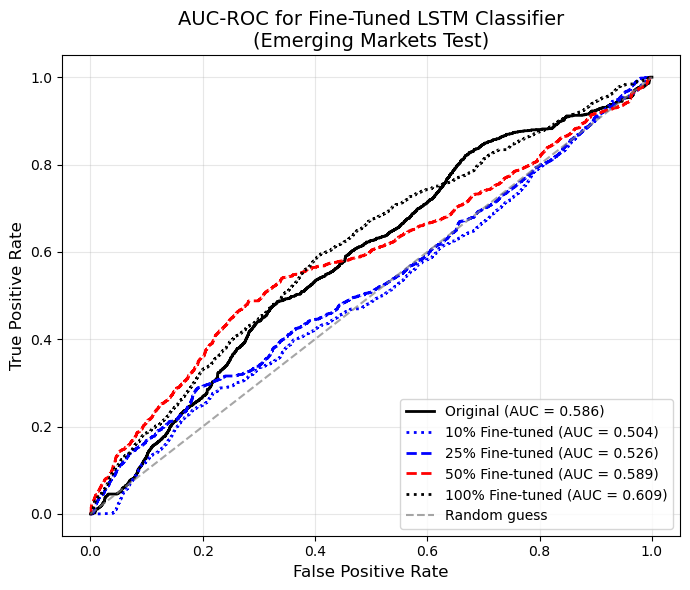

In [1]:
from src.visualizations.auc import plot_roc_curves
import pandas as pd

results_df = pd.read_csv('fine-tuned-best-results.csv', index_col=0)
columns_to_keep = [col for col in results_df.columns.tolist() if f'10 Epochs' in col or col == 'Original']
results_df = results_df[columns_to_keep]

results_df.columns = ['Original', f'10% Fine-tuned', f'25% Fine-tuned', f'50% Fine-tuned', f'100% Fine-tuned']

linestyle_map = {
    'Original': '-k',
    f'10% Fine-tuned': ':b',
    f'25% Fine-tuned': '--b',
    f'50% Fine-tuned': '--r',
    f'100% Fine-tuned': ':k',
}
plot_roc_curves(
    results_df=results_df,
    linestyle_map=linestyle_map,
    title='AUC-ROC for Fine-Tuned LSTM Classifier\n(Emerging Markets Test)',
    figsize=(7, 6)
)